Importing libraries and Modells 

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score

Import CSV file and print the data

In [20]:
FILE_PATH = "../dataset/all_zones_complete_2025.csv"

df = pd.read_csv(FILE_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["timestamp_local"] = df["timestamp"].dt.tz_convert("Europe/Stockholm")

print(f"Inläst: {df.shape[0]} rader, {df.shape[1]} kolumner")

Inläst: 8760 rader, 18 kolumner


In [ ]:
# Skapa prisskillnad (spread) mellan SE4 och SE1
df["price_spread_se4_se1"] = df["price_se4_eur_mwh"] - df["price_se1_eur_mwh"]

# välj ut 5 fokucerade features
FEATURES = [
    "price_se3_eur_mwh",
    "price_spread_se4_se1",
    "temp_se3_c",
    "wind_se3_kmh",
    "wind_se4_kmh",
]


# rensa eventuella saknade värden
df_clean = df.dropna(subset=FEATURES).copy()
X = df_clean(FEATURES)

print(f"Träningsdata X form: {X.shape}")

KeyError: ['price_spread_se4_se_1']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\jarll\AppData\Local\Temp\ipykernel_38728\1239138674.py:17: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


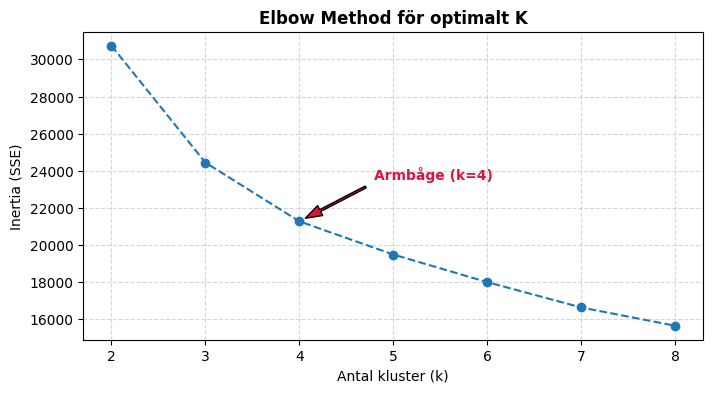

In [14]:
inertia = []
k_range = list(range(2, 9))

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertia.append(kmeans_test.inertia_)

# --- Beräkna armbågens placering geometriskt ---
p1 = np.array([k_range[0], inertia[0]])
p2 = np.array([k_range[-1], inertia[-1]])

distances = []
for k_val, inert_val in zip(k_range, inertia):
    p = np.array([k_val, inert_val])
    # Ortogonalt avstånd till linjen mellan p1 och p2
    d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
    distances.append(d)

elbow_idx = int(np.argmax(distances))
elbow_k = k_range[elbow_idx]
elbow_inertia = inertia[elbow_idx]

# --- Plotta ---
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", linestyle="--", color="#1f77b4")

# Pil och text mot armbågen
plt.annotate(
    f"Armbåge (k={elbow_k})",
    xy=(elbow_k, elbow_inertia),
    xytext=(elbow_k + 0.8, elbow_inertia + (max(inertia) - min(inertia)) * 0.15),
    arrowprops=dict(facecolor="crimson", shrink=0.08, width=1.5, headwidth=8),
    fontweight="bold",
    color="crimson",
    fontsize=10,
)

plt.title("Elbow Method för optimalt K", fontweight="bold")
plt.xlabel("Antal kluster (k)")
plt.ylabel("Inertia (SSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [9]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

# Skriv ut storleken på varje kluster
print("Antal timmar per kluster:")
print(df_clean["cluster"].value_counts().sort_index())

Antal timmar per kluster:
cluster
0    1242
1    2678
2    2406
3    2434
Name: count, dtype: int64


In [10]:
cluster_summary = df_clean.groupby("cluster")[features].mean().round(2)
display(cluster_summary)

,price_se3_eur_mwh,price_se4_eur_mwh,temp_se3_c,wind_se3_kmh,wind_se4_kmh
cluster,,,,,
0,127.09,144.52,2.81,8.83,13.83
1,17.59,23.53,9.19,17.39,24.42
2,36.26,55.06,16.02,9.00,13.84
3,46.66,63.84,2.67,9.53,13.78


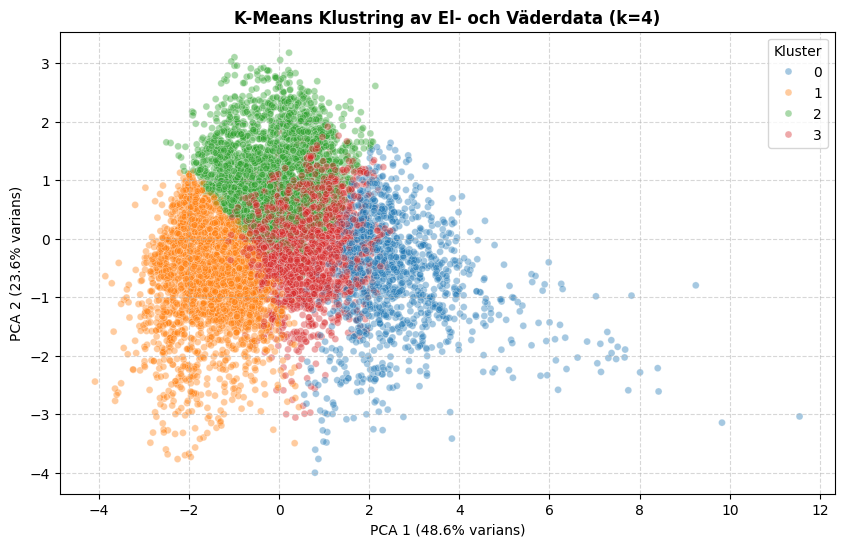

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean["pca_1"] = X_pca[:, 0]
df_clean["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, x="pca_1", y="pca_2", hue="cluster", palette="tab10", alpha=0.4, s=25
)

plt.title(f"K-Means Klustring av El- och Väderdata (k={OPTIMAL_K})", fontweight="bold")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varians)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varians)")
plt.legend(title="Kluster", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
df_clean.to_csv("all_zones_clustered_2025.csv", index=False)
print("Färdigt! Sparat till 'all_zones_clustered_2025.csv'.")

k = 2 | Inertia: 30736.1 | Silhouette Score: 0.2643
k = 3 | Inertia: 24440.8 | Silhouette Score: 0.2405
k = 4 | Inertia: 21272.1 | Silhouette Score: 0.2250
k = 5 | Inertia: 19487.1 | Silhouette Score: 0.1958
k = 6 | Inertia: 17999.0 | Silhouette Score: 0.1920
k = 7 | Inertia: 16635.2 | Silhouette Score: 0.1899
k = 8 | Inertia: 15650.3 | Silhouette Score: 0.1924


C:\Users\jarll\AppData\Local\Temp\ipykernel_38728\2374997536.py:32: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.abs(np.cross(p2 - p1, p1 - np.array([k_val, inert_val])))


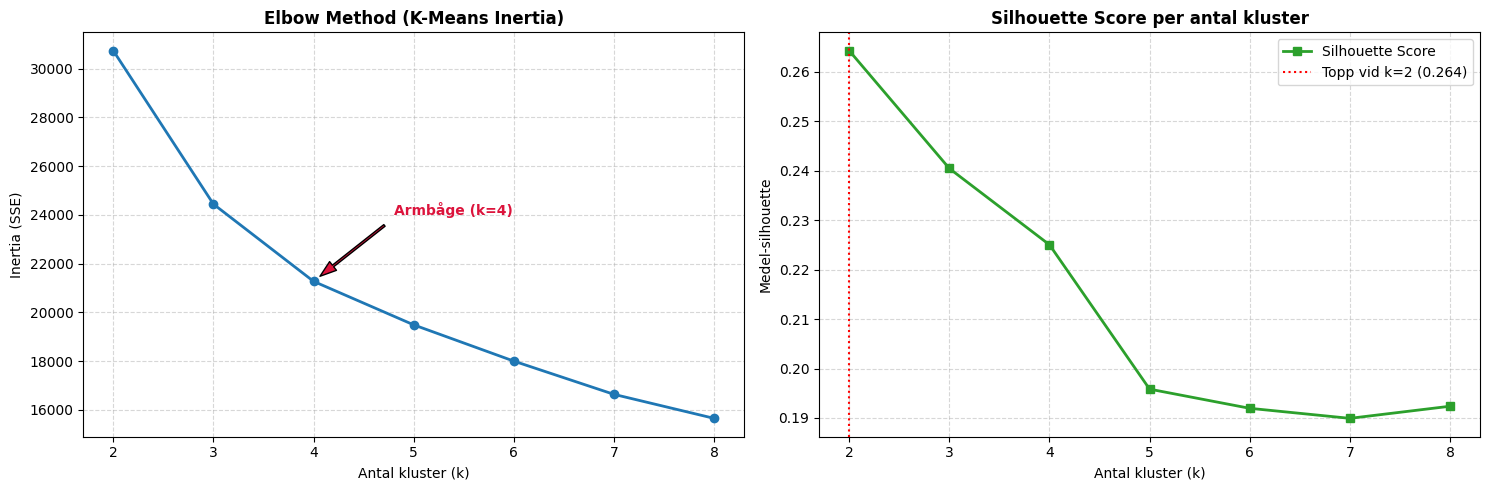

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = list(range(2, 9))
inertia_scores = []
silhouette_scores = []

np.random.seed(42)
sample_idx = np.random.choice(
    X_scaled.shape[0], size=min(2500, X_scaled.shape[0]), replace=False
)
X_sample = X_scaled[sample_idx]

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X_scaled)

    inertia_scores.append(kmeans_model.inertia_)
    sil_score = silhouette_score(X_sample, labels[sample_idx])
    silhouette_scores.append(sil_score)
    print(
        f"k = {k} | Inertia: {kmeans_model.inertia_:.1f} | Silhouette Score: {sil_score:.4f}"
    )

# --- Beräkna armbågen ---
p1 = np.array([k_range[0], inertia_scores[0]])
p2 = np.array([k_range[-1], inertia_scores[-1]])

distances = [
    np.abs(np.cross(p2 - p1, p1 - np.array([k_val, inert_val])))
    / np.linalg.norm(p2 - p1)
    for k_val, inert_val in zip(k_range, inertia_scores)
]
elbow_idx = int(np.argmax(distances))
elbow_k = k_range[elbow_idx]
elbow_inertia = inertia_scores[elbow_idx]

# --- Plotta båda mätvärdena ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graf 1: Inertia med pil mot armbågen
ax1.plot(
    k_range,
    inertia_scores,
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label="Inertia",
)
ax1.annotate(
    f"Armbåge (k={elbow_k})",
    xy=(elbow_k, elbow_inertia),
    xytext=(
        elbow_k + 0.8,
        elbow_inertia + (max(inertia_scores) - min(inertia_scores)) * 0.18,
    ),
    arrowprops=dict(facecolor="crimson", shrink=0.08, width=1.5, headwidth=8),
    fontweight="bold",
    color="crimson",
    fontsize=10,
)
ax1.set_title("Elbow Method (K-Means Inertia)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Antal kluster (k)", fontsize=10)
ax1.set_ylabel("Inertia (SSE)", fontsize=10)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Graf 2: Silhouette Score
ax2.plot(
    k_range,
    silhouette_scores,
    marker="s",
    linewidth=2,
    color="#2ca02c",
    label="Silhouette Score",
)
best_k = k_range[int(np.argmax(silhouette_scores))]
ax2.axvline(
    x=best_k,
    color="red",
    linestyle=":",
    label=f"Topp vid k={best_k} ({max(silhouette_scores):.3f})",
)
ax2.set_title("Silhouette Score per antal kluster", fontsize=12, fontweight="bold")
ax2.set_xlabel("Antal kluster (k)", fontsize=10)
ax2.set_ylabel("Medel-silhouette", fontsize=10)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()